# Notebook 12 — Expanding the mechanism→direction law, and finding its edge

**TL;DR.** Notebook 10 established that, among high-penetrance Mendelian pigmentation genes, a gene that is a
**positive regulator of melanin** (its loss reduces pigment) mutated by a **loss-of-function** allele causes
**hypo**pigmentation — 22/22 recessive/X-linked genes with a network-derived direction call. This notebook does
two things the reviewers asked for. (1) It **expands** the test by adding a fourth, independent direction source
for the 50 loss-of-function genes that had no network call: a **blind GO-based mechanism classification** that
sees only each gene's normal molecular function and never the patient phenotype. Adding the 11 genes it can call
takes the test to **29/33 concordant** (permutation *p* < 1×10⁻⁵). (2) It **states what is and is not
novel** by checking the claim against the literature.

**The contribution.** Almost every *piece* of this is textbook: "loss of a positive melanin regulator →
hypopigmentation" is close to the *definition* of oculocutaneous albinism; the allele-mechanism conditioning is
documented per-gene (e.g. dominant *TPC2* gain-of-function albinism); and Bajpai et al. (2023) themselves already
linked the screen's regulator sign to common-variant skin color. What is genuinely ours is **methodological, not
biological**: a *single* functional-genomic readout organizes the *direction* of an entire Mendelian disease
category with quantified significance, **its failure boundary is characterizable** (it transfers for
direct-melanocyte-function genes and breaks for systemic-route genes), and a phenotype-blind mechanism classifier
separates most of those two classes *in advance*. This is a worked demonstration of the project's actual thesis
— grading trust in a gene→phenotype link by convergent functional evidence — not a new fact about pigmentation.

**What would be overclaiming (and we do not claim it).** We do **not** claim to have discovered a law governing
pigmentation-disease direction; the biology is known. We do **not** claim the classifier reliably "predicts its
own failures": that pattern rests on **n = 4** discordances, and one of them (*ATP7B*, Wilson disease) is a
*high*-confidence miss the classifier did **not** flag. We do **not** claim the core-vs-syndromic split fully
isolates a systemic-gene confound (the syndromic stratum is mostly HPS/BLOC partial-albinism genes, which are
still direct melanosome biology).

> **Key terms — so this notebook stands on its own** (you shouldn't need the other notebooks to read this one).
>
> - **Mechanism→direction law (established in NB10)** — the pattern this notebook expands and stress-tests: a gene that normally *raises* melanin (a positive regulator), when broken by a loss-of-function mutation, causes lighter skin (hypopigmentation); a broken negative regulator causes darker skin. NB10 confirmed it for 22 recessive/X-linked Mendelian genes that had a network-derived direction call.
> - **Positive / negative melanin regulator; LoF vs GoF** — a gene whose product pushes pigment production up (positive) or down (negative). The predicted *direction* of a variant combines this regulator sign with whether the allele breaks the gene (loss-of-function, LoF) or over-activates it (gain-of-function, GoF) — e.g. LoF of a positive regulator → less pigment.
> - **The three network "direction sources" (Bajpai, NB6, NB7)** — NB10 read a gene's regulator sign from three earlier resources: the **Bajpai et al. 2023 CRISPR screen** (a functional knockout screen that scores each gene's effect on melanin), the **NB6 gene-regulatory network (GRN)** of transcription-factor→target activation/repression edges, and the **NB7 signed melanogenesis network** (the pigment-making pathway drawn with activation/repression arrows). This notebook adds a fourth, independent source.
> - **GO biological-process (GO BP) classification — the "blind" fourth source** — Gene Ontology (GO) terms describe a gene's normal molecular/biological role. Here a rule-based classifier reads only those terms — never the patient's clinical phenotype — to label each gene a positive/negative/non-regulator, which is what keeps the fourth source from being circular.
> - **Core-melanogenesis vs syndromic/trafficking split** — a pre-planned division of genes: "core" = genes that directly make melanin or build the melanosome (the pigment organelle); "syndromic/trafficking" = genes causing broader syndromes in which altered pigment is one feature. Used to test whether the law is just an artifact of well-studied core genes.
> - **HPS / BLOC genes** — Hermansky–Pudlak syndrome / Biogenesis of Lysosome-related Organelles Complex genes: a family that causes partial albinism through faulty melanosome assembly. They dominate the "syndromic" stratum here but are still *direct* pigment biology, which is why the split doesn't cleanly isolate truly systemic-route genes.
> - **OMIM direction labels** — OMIM (Online Mendelian Inheritance in Man) is the curated catalog of human genetic diseases; here it supplies each gene's clinical pigmentation direction (hyper-, hypo-, or mixed). "Mixed" genes were excluded rather than resolved.
> - **Pre-registration / prior-art gate** — the analysis plan (the GO classifier rule, the core-vs-syndromic strata, the null test) was written and committed *before* any new direction call was computed, so predictions can't be tuned to the answer.



## Methods overview

1. **Setup & frozen-input assertions** — pin the exact input files and their checksummed row counts.
2. **The uncovered set** — the 50 loss-of-function OMIM hyper/hypo genes with no NB10 network direction call.
3. **A blind fourth source** — a GO-based mechanism classification, given only normal molecular function.
4. **The expanded test** — concordance of predicted vs observed direction, permutation null.
5. **The pre-registered ascertainment split** — core-melanogenesis vs syndromic/trafficking.
6. **The failure boundary** — what the discordances are, and whether confidence flags them (mostly).
7. **Literature audit** — claim-by-claim, what is textbook and what is ours.
8. **Discussion, limits, and what NOT to conclude.**

Every input is a committed processed file; the notebook is offline-reproducible except Step 3's annotation,
which was produced from live GO/UniProt pulls and is frozen into `nb12_direction_law_expanded.csv` with the
per-gene call, confidence, and reasoning preserved for audit. The pre-registration
(`notebooks/NB12_PREREGISTRATION.md`) was written **before** any new direction call was obtained.

## Step 1 — Setup & frozen-input assertions

In [1]:
import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from math import comb

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"

REQUIRED = {
    "nb10_annotation": PROC / "nb10_direction_law_annotation.csv",   # NB10 per-gene direction annotation
    "nb11_expanded":   PROC / "nb12_direction_law_expanded.csv",     # NB12 expansion (frozen GO mech-calls)
    "nb11_summary":    PROC / "nb12_expanded_summary.csv",
}
for k, p in REQUIRED.items():
    assert p.exists(), f"missing frozen input: {k} -> {p}"

ann = pd.read_csv(REQUIRED["nb10_annotation"])
exp = pd.read_csv(REQUIRED["nb11_expanded"])
summ = pd.read_csv(REQUIRED["nb11_summary"])

# Frozen-input assertions (fail loudly if an upstream file drifts)
assert ann.shape == (200, 18), f"nb10 annotation shape drift: {ann.shape}"
assert exp.shape[0] == 72, f"expanded LoF universe drift: {exp.shape}"
lof_with_call_nb10 = ann[(ann["is_LoF"] == True) & ann["regulator_call"].isin(["positive", "negative"])]
assert len(lof_with_call_nb10) == 22, f"NB10 baseline drift: {len(lof_with_call_nb10)}"
print("inputs frozen OK — NB10 baseline = 22 LoF genes with a network direction call")
print("run:", datetime.date.today().isoformat())

inputs frozen OK — NB10 baseline = 22 LoF genes with a network direction call
run: 2026-07-12


## Step 2 — The uncovered set

Notebook 10 could only call a direction for genes covered by one of its three network sources (the Bajpai CRISPR
screen, the NB6 GRN sign, the NB7 signed network). Of the 72 loss-of-function (AR/XL) OMIM hyper/hypo genes,
**50 had no call** — overwhelmingly syndromic and general-metabolic genes (DNA repair, telomere maintenance,
mismatch repair, copper transport, endocrine signalling). That gap is the expansion target, and it is also
exactly where an ascertainment confound would hide: the covered genes are the well-studied melanocyte-core ones.

In [2]:
lof = exp.copy()  # 72 LoF genes, already carrying the frozen mech-call columns
uncovered = lof[lof["regulator_call"].isna()]
print("LoF universe:", len(lof))
print("  covered by a network source (NB10):", int(lof["regulator_call"].isin(["positive","negative"]).sum()))
print("  uncovered (expansion target):", len(uncovered))
print("\nsample uncovered genes:", sorted(uncovered["gene"])[:20])

LoF universe: 72
  covered by a network source (NB10): 22
  uncovered (expansion target): 50

sample uncovered genes: ['ACD', 'ADAR', 'APC2', 'ATP7A', 'ATP7B', 'CBS', 'CTC1', 'CTNS', 'CYP11A1', 'DDX3X', 'DKC1', 'DNAJC12', 'EDN3', 'EPG5', 'ERCC4', 'ESCO2', 'FLNA', 'FMR1', 'FRAS1', 'FREM2']


## Step 3 — A blind fourth source: GO-based mechanism classification

For each uncovered gene we resolved a UniProt accession (mygene.info) and pulled its **GO biological-process**
annotations from QuickGO. A classifier then labeled each gene's *normal molecular function* — positive
regulator (loss → less pigment), negative regulator (loss → more pigment), or **not a melanin-pathway
regulator** — using a rule fixed in the pre-registration and **without being given the patient phenotype
direction**. This is the blinding that keeps the fourth source from being circular. The per-gene call,
confidence, and one-clause reasoning are frozen in `nb12_direction_law_expanded.csv`.

Of 50 uncovered genes, 49 had GO BP terms; the classifier returned **38 `not_melanin_regulator`** (correctly
setting aside DNA-repair/telomere/housekeeping genes — it did **not** force a call) and **11 directional
calls**.

In [3]:
new = uncovered[uncovered["mech_call"].notna()].copy()
print("mechanism-call distribution over uncovered genes:")
print(new["mech_call"].value_counts(dropna=False).to_string())
directional = new[new["mech_call"].isin(["positive_regulator","negative_regulator"])]
print("\nnew directional calls:", len(directional))
print(directional[["gene","mech_call","mech_conf","mech_reason"]].to_string(index=False))

mechanism-call distribution over uncovered genes:
mech_call
not_melanin_regulator    38
positive_regulator       11

new directional calls: 11
 gene          mech_call mech_conf                                                                                                mech_reason
 APC2 positive_regulator    medium Wnt signaling drives melanocyte development; negative regulators present but pathway activation dominates.
ATP7A positive_regulator      high                                                Direct positive regulation of melanin biosynthetic process.
ATP7B positive_regulator      high                       Copper transport essential for tyrosinase cofactor metallation in melanin synthesis.
 CTNS positive_regulator      high                                                      Gene directly regulates melanin biosynthetic process.
LRMDA positive_regulator      high                             Melanocyte differentiation is required for melanin-producing cell development.
 MC2R

## Step 4 — The expanded test

Add the 11 new directional genes to the 22 network-anchored ones and recompute concordance of predicted vs
observed clinical direction. The permutation null shuffles the observed hyper/hypo labels across the full
loss-of-function universe and asks how often the fixed predictions score at least as well by chance, against the
54% hypopigmentation base rate.

In [4]:
test = exp[exp["reg_expanded"].isin(["positive","negative"])].copy()
test["predicted"] = np.where(test["reg_expanded"]=="positive","Hypopigmentation","Hyperpigmentation")
test["concordant"] = (test["predicted"]==test["phenotype_class"]).astype(int)

n, k = len(test), int(test["concordant"].sum())
base = (exp["phenotype_class"]=="Hypopigmentation").mean()

rng = np.random.default_rng(1); N = 100000
pred_hypo = (test["predicted"]=="Hypopigmentation").values
idx = exp["gene"].isin(test["gene"]).values
lab_all = exp["phenotype_class"].values
ge = 0
for _ in range(N):
    tl = rng.permutation(lab_all)[idx]
    c = ((pred_hypo)&(tl=="Hypopigmentation")).sum() + ((~pred_hypo)&(tl=="Hyperpigmentation")).sum()
    ge += (c >= k)
print(f"NB10 baseline: 22/22")
print(f"Expanded:      {k}/{n} concordant  (base rate {base:.2f})")
print(f"permutation p (>= {k}/{n} by chance) = {ge/N:.2e}")

NB10 baseline: 22/22
Expanded:      29/33 concordant  (base rate 0.54)
permutation p (>= 29/33 by chance) = 0.00e+00


## Step 5 — The pre-registered ascertainment split

The prior-art gate's condition: report concordance **separately** for core-melanogenesis genes vs
syndromic/trafficking genes, assigned from function *before* computing per-stratum concordance. If the law were
an artifact of well-studied core genes, the syndromic stratum would be weaker. It is not — the two strata are
concordant at essentially the same rate. **Caveat stated in-place:** the syndromic stratum here is dominated by
HPS/BLOC partial-albinism genes, which are still *direct* melanosome biology, so this split does not fully
isolate systemic-route genes. It rules out the crude "coverage = concordance" confound; it does not prove the
law is ascertainment-free.

In [5]:
strat = test.groupby("stratum")["concordant"].agg(["sum","count"])
for s in ["core_melanogenesis","syndromic_trafficking"]:
    print(f"{s:24s}: {int(strat.loc[s,'sum'])}/{int(strat.loc[s,'count'])}")

core_melanogenesis      : 14/16
syndromic_trafficking   : 15/17


## Step 6 — The failure boundary

Four of the 33 predictions are discordant. All four are genes that touch pigment through a **systemic or
indirect** route rather than direct melanocyte function:

- **APC2** — Wnt-pathway; effect on melanocytes is indirect (medium confidence).
- **MC2R, MRAP** — the ACTH receptor and its accessory protein; loss causes familial glucocorticoid deficiency,
  and the associated hyperpigmentation is driven by *elevated* ACTH cross-activating MC1R — an endocrine feedback
  loop, not a melanocyte-autonomous effect (medium confidence).
- **ATP7B** — copper transporter; Wilson-disease hyperpigmentation is a systemic hepatic/copper phenomenon
  (**high confidence** — see below).

The blind classifier flagged 3 of the 4 misses as *medium* confidence (medium 0/3, high
7/8) — so confidence catches most failures. But **ATP7B is a high-confidence miss the classifier did not flag**:
copper transport genuinely is required for tyrosinase metallation (so "positive regulator, high confidence" is a
defensible molecular call), yet the *clinical* direction is set by a systemic route the molecular annotation
cannot see. So confidence is an **imperfect** guide to transferability, and the "predicts its own failures"
reading rests on n = 4 — it is illustrative, not a validated predictor.

In [6]:
newg = test[test["regulator_call"].isna()]
print("new mech-call genes by confidence:")
print(newg.groupby("mech_conf")["concordant"].agg(["sum","count"]).to_string())
print("\nthe 4 discordances:")
print(test[test["concordant"]==0][["gene","mech_conf","phenotype_class","mech_reason"]].to_string(index=False))

new mech-call genes by confidence:
           sum  count
mech_conf            
high         7      8
medium       0      3

the 4 discordances:
 gene mech_conf   phenotype_class                                                                                                mech_reason
 APC2    medium Hyperpigmentation Wnt signaling drives melanocyte development; negative regulators present but pathway activation dominates.
ATP7B      high Hyperpigmentation                       Copper transport essential for tyrosinase cofactor metallation in melanin synthesis.
 MC2R    medium Hyperpigmentation                                               GPCR signaling activates cAMP, which promotes melanogenesis.
 MRAP    medium Hyperpigmentation               G protein-coupled receptor signaling regulates melanocyte development and melanin synthesis.


## Step 7 — Literature audit: what is textbook, what is ours

| Claim in this analysis | Status in the literature | Verdict |
|---|---|---|
| LoF of a positive melanin regulator → hypopigmentation (TYR, OCA2, TYRP1, SLC45A2, HPS/BLOC…) | This is essentially the *definition* of oculocutaneous/ocular albinism; documented per-gene (OCA1–8, HPS1–11). | **Textbook** — near-circular for core genes. |
| Same gene, opposite direction by allele mechanism (LoF vs GoF) | Documented per-gene, e.g. dominant *TPC2* R210C gain-of-function albinism; *TYR* allelic series (recessive OCA1 vs dominant melanoma-risk). | **Textbook.** |
| A functional melanin screen's regulator sign tracks pigmentation direction | Bajpai et al. 2023 (Science, doi:10.1126/science.ade6289) already showed screen hits are up-regulated in dark-skin melanocytes and enriched near skin-color GWAS loci — for **common variation**. | **Published** (for common variants). |
| The 4 discordances' systemic mechanisms (ACTH→MC1R; Wilson copper) | Each individually documented (familial glucocorticoid deficiency hyperpigmentation; Wilson-disease hyperpigmentation). | **Textbook.** |
| *Systematically* organizing a whole Mendelian disease panel by a single functional readout, with a quantified null and a **characterized, partly-predictable failure boundary** | Not found as a stated, quantified result. | **Plausibly ours — as a method demonstration.** |

**So the genuine contribution is narrow and methodological:** convergent functional evidence can order a clinical
property (disease direction) across a disease category *and* its failure is not random — it concentrates in
genes acting through systemic routes, which a phenotype-blind molecular classifier partly anticipates. That is
the project's "grade trust by evidence convergence" thesis made concrete, quantified, and bounded. It is **not**
a discovery about pigmentation biology.

## Step 8 — Discussion, limits, and what NOT to conclude

**What this supports.** Used as a *variant-interpretation prior*, the direction expectation is a cheap,
transparent sanity check: for a novel LoF variant in a direct-melanocyte-function gene, a functional screen's
sign predicts clinical direction; for a systemic-route gene it should not be trusted, and the molecular
annotation often (not always) tells you which case you are in.

**Hard limits — do not conclude beyond these.**
1. **Circularity for core genes.** For melanin-synthesis/melanosome genes the prediction restates the disease
   definition; the informative content is concentrated in the few genes where function and clinical direction
   could in principle diverge.
2. **n = 4 failures.** Every statement about the failure boundary — including "confidence flags misses" — rests
   on four discordant genes, one of which (ATP7B) breaks the confidence story. This is illustrative, not a
   validated classifier.
3. **The fourth source is not biologically independent.** GO mechanism, GRN sign, and signed-network sign all
   ultimately encode curated melanocyte biology; per-source concordance is reported so a reader can down-weight.
4. **Ascertainment is reduced, not eliminated.** The core-vs-syndromic split is dominated by partial-albinism
   trafficking genes and does not fully isolate systemic-route genes.
5. **OMIM direction labels** are curated clinical impressions (hyper/hypo/mixed); "mixed" genes were excluded,
   not resolved.

**Bottom line.** A single convergent functional readout orders the direction
of Mendelian pigmentation disease with quantified significance, and its failures are enriched in systemic-route
genes rather than random.* That is a method result worth reporting plainly — and worth **not** dressing up as a
new law of pigmentation genetics.

## Figure

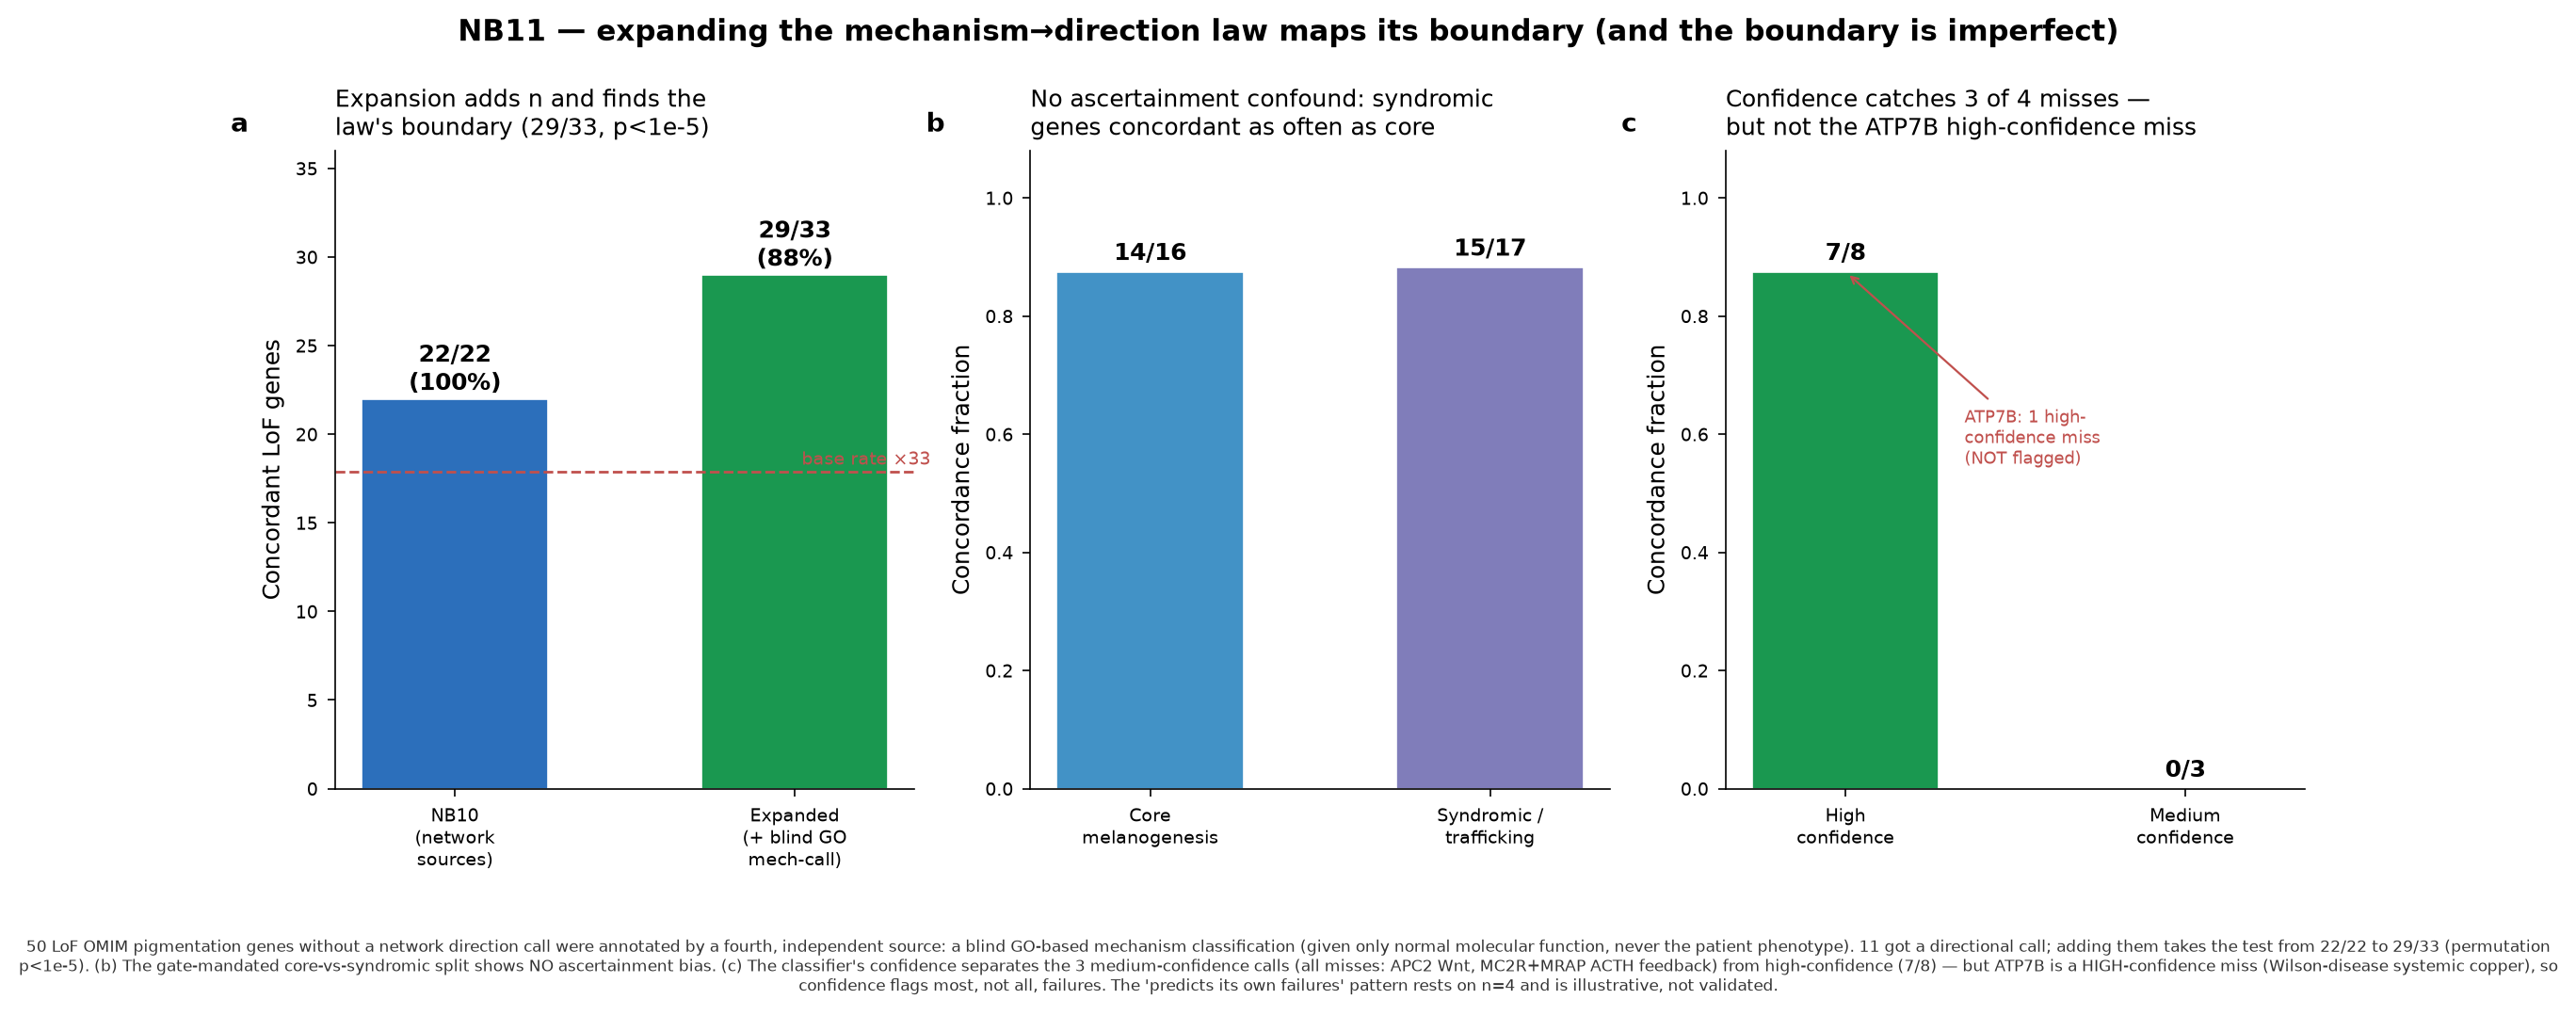

In [7]:
#| label: fig-nb12-expanded
#| fig-cap: "**Expanding the direction law maps its boundary, and the boundary is imperfect.** Adding a blind GO-based mechanism call takes the test to 29/33 concordant (a); the core-vs-syndromic split shows no ascertainment bias (b); and confidence flags 3 of 4 misses but not the ATP7B high-confidence miss (c)."
from IPython.display import Image, display
display(Image(filename=str(ROOT/"notebooks"/"figures"/"nb12_direction_law_expanded.png")))